# **R/S BENCHMARK — $\lambda$ MAPS**

Scatter of every design point at a chosen time step.

Loads `dataset_unique_<split>_<time_step>_benchmark.pkl` from
[`01_generate_dataset.ipynb`](01_generate_dataset.ipynb).

## **1. Libraries**

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })
import numpy as np
import pandas as pd

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import dill

## **2. Config**

`n_latent_samples` and `times` must match [`01_generate_dataset.ipynb`](01_generate_dataset.ipynb). They name the file being loaded. Pick the time step with `time_index` (its position in `times`) rather than typing the float directly, to avoid a mismatch against the saved filename.

In [6]:
n_latent_samples = 2500     # must match stage 1 — it names the file being loaded
times            = np.linspace(0, 150, 10, endpoint=True)  # must match stage 1

split       = 'train'   # 'train' or 'val'
time_index  = 5          # index into `times` — change this to look at a different time step
time_step   = times[time_index]

fig_size   = (5, 4)      # size of each individual figure, in inches
fig_format = 'png'       # format each figure is saved in ('pdf', 'png', ...)
fig_dpi    = 300         # resolution the figure is saved at (dots per inch)

label_fontsize = 14   # font size of the axis labels ($R$, $S$) and colorbar label
tick_fontsize  = 14   # font size of the tick numbers, on both axes and the colorbar

xlim = None   # e.g. (2.5, 8.0) to fix the R axis; None = auto-scaled to the data
ylim = None   # e.g. (0.0, 4.5) to fix the S axis; None = auto-scaled to the data

# Per-lambda colorbar limits as (vmin, vmax). None = auto-scaled to that lambda's own range.
lambda_vlim = {
                'lambda 1': None,
                'lambda 2': None,
                'lambda 3': None,
                'lambda 4': None,
              }

print(f"Plotting t = {time_step:.2f} years ({split} split)")

Plotting t = 83.33 years (train split)


## **3. Load the dataset**

In [7]:
pkl_name = f'{n_latent_samples}_dataset_unique_{split}_{time_step}_benchmark'

with open(f'{pkl_name}.pkl', 'rb') as f:
    df = dill.load(f)

print(f"{len(df)} design points loaded")
df.head()

500 design points loaded


,r,s,lambda 1,lambda 2,lambda 3,lambda 4,Processing time (s)
0,5.929063,2.220905,0.244526,6.729753,0.110592,0.093410,0.006401
1,6.100586,1.705514,0.836302,8.407184,0.136558,0.105728,0.004852
2,5.237327,2.508148,-0.325476,5.647710,0.138476,0.167695,0.004460
3,3.477975,1.311640,0.140490,11.058642,0.122642,0.143939,0.003986
4,4.890498,3.023671,-0.982496,5.132088,0.124963,0.105506,0.004311


## **4. $\lambda$ maps**

One figure per $\lambda_i$. Each figure was saved as `<pkl_name>_lambda_<i>.<fig_format>`, i.e. the same name as the
`.pkl` this notebook loaded.

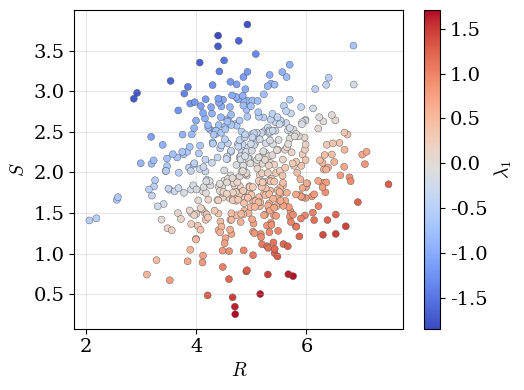

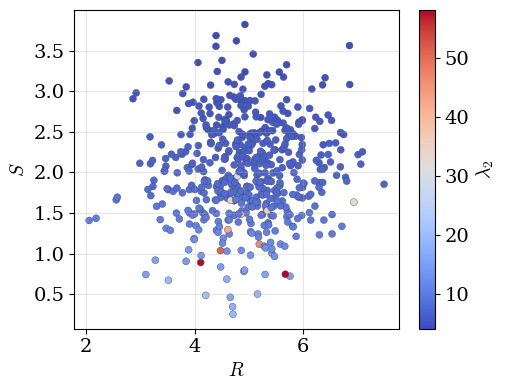

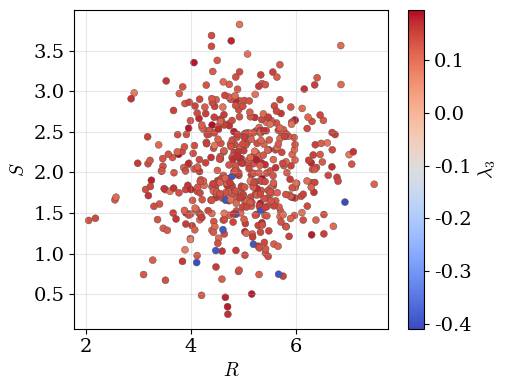

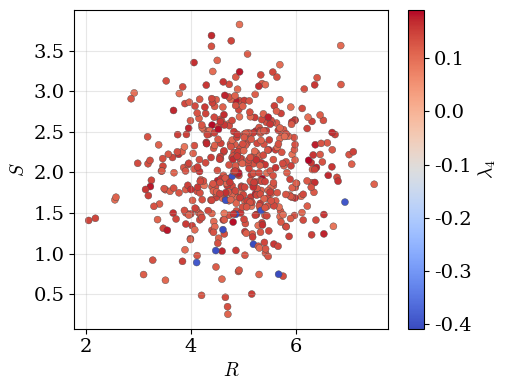

In [8]:
lambda_cols = ['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4']
figs = {}

for col in lambda_cols:
    mask       = df[col].notna()
    vmin, vmax = lambda_vlim.get(col) or (None, None)
    idx        = col.split(' ')[1]

    fig, ax = plt.subplots(figsize=fig_size)
    sc = ax.scatter(df.loc[mask, 'r'], df.loc[mask, 's'], c=df.loc[mask, col],
                     cmap='coolwarm', s=25, edgecolor='0.3', linewidth=0.3, vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f'$\\lambda_{{{idx}}}$', fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_fontsize)
    ax.set_xlabel('$R$', fontsize=label_fontsize)
    ax.set_ylabel('$S$', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    fig.savefig(f'{pkl_name}_lambda_{idx}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    figs[col] = fig
    plt.show()